# E-Commerce Churn & LTV — Phase 2: Initial + Detailed EDA

**MLDLC stage:** Step 3 (Initial EDA — Data Understanding) + Step 5 (Detailed EDA), per `MLDLC_best_practices`.

**Rules for this notebook (MLOps hygiene):**
- No modeling. No feature engineering. No leakage-prone decisions here — this is pure understanding.
- No hardcoded local file paths — the data path is a config variable set once, in one cell.
- Random seed fixed for anything with sampling.
- The raw CSV is never overwritten in this notebook.
- Last cell prints one clean summary block — **copy that block back into chat when you're done**, so the next notebook (feature engineering) is built from what your data actually shows, not from assumptions.

**Known facts about this dataset already confirmed before this notebook was written:**
- 50,000 rows, 25 columns.
- Target column: `Churned` (0 = active, 1 = churned).
- There is **no `Customer_ID` column** in the raw file — this notebook creates one from the row index.
- Column is `Returns_Rate` (not `Return_Rate`).


In [1]:
# --- Setup ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

print("Setup complete. Random seed:", RANDOM_SEED)


Setup complete. Random seed: 42


## 1. Load Data

Upload the CSV directly in Colab (left sidebar → Files → upload), then set `DATA_PATH` below to match the uploaded filename. No absolute local paths.

In [2]:
# --- Config: set this to the uploaded file's name/path in your Colab session ---
DATA_PATH = "ecommerce_customer_churn_dataset.csv"  # <-- change if your uploaded filename differs

df = pd.read_csv(DATA_PATH)

# The raw file has no entity key — synthesize one now, before anything else touches the data.
df = df.reset_index().rename(columns={"index": "Customer_ID"})

print("Loaded:", df.shape)


Loaded: (50000, 26)


## 2. Shape & Structure

*(MLDLC Q: How big is the data? How does it look?)*

In [3]:
print("Shape (rows, cols):", df.shape)
display(df.head())


Shape (rows, cols): (50000, 26)


,Customer_ID,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,9.0,94.72,34.0,46.40,2.0,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,19.5,82.45,71.0,57.96,9.2,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,9.1,165.52,11.0,12.24,11.5,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,15.0,147.33,47.0,44.10,5.4,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,32.5,141.30,73.0,25.20,5.5,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [4]:
display(df.sample(5, random_state=RANDOM_SEED))


,Customer_ID,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
33553,33553,33.0,Female,Germany,Hamburg,4.8,5.0,NaN,6.5,62.1,5.0,7.0,119.41,12.0,18.6,NaN,0.0,5.0,3.0,4.5,10.0,3.0,855.25,NaN,0,Q2
9427,9427,30.0,Female,UK,London,1.5,18.0,41.3,12.6,31.7,NaN,16.0,34.79,23.0,17.2,3.1,31.4,3.0,4.0,21.9,30.6,2.0,480.17,2576.0,0,Q3
199,199,24.0,Male,USA,Phoenix,5.0,4.0,14.9,5.4,63.3,0.0,11.0,202.86,15.0,68.5,6.9,8.1,7.0,NaN,23.6,12.9,1.0,2351.35,848.0,1,Q2
12447,12447,23.0,Male,Canada,Vancouver,0.5,29.0,53.9,12.0,38.7,12.0,24.0,188.73,24.0,5.0,3.1,45.1,3.0,3.0,79.3,33.6,3.0,3916.60,3174.0,1,Q2
39489,39489,52.0,Male,Germany,Berlin,3.0,8.0,19.1,5.8,67.4,2.0,8.0,101.68,14.0,62.0,0.3,0.0,6.0,3.0,12.2,10.4,3.0,684.17,1270.0,0,Q3


## 3. Data Types & Schema Check

*(MLDLC Q: What is the data type of each column?)*

Compares actual dtypes against what was expected going into this notebook, so any surprise gets caught here — not three notebooks later.

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Customer_ID                    50000 non-null  int64  
 1   Age                            47505 non-null  float64
 2   Gender                         50000 non-null  object 
 3   Country                        50000 non-null  object 
 4   City                           50000 non-null  object 
 5   Membership_Years               50000 non-null  float64
 6   Login_Frequency                50000 non-null  float64
 7   Session_Duration_Avg           46601 non-null  float64
 8   Pages_Per_Session              47000 non-null  float64
 9   Cart_Abandonment_Rate          50000 non-null  float64
 10  Wishlist_Items                 46000 non-null  float64
 11  Total_Purchases                50000 non-null  float64
 12  Average_Order_Value            50000 non-null 

In [6]:
expected_numeric = [
    "Age", "Membership_Years", "Login_Frequency", "Session_Duration_Avg", "Pages_Per_Session",
    "Cart_Abandonment_Rate", "Wishlist_Items", "Total_Purchases", "Average_Order_Value",
    "Days_Since_Last_Purchase", "Discount_Usage_Rate", "Returns_Rate", "Email_Open_Rate",
    "Customer_Service_Calls", "Product_Reviews_Written", "Social_Media_Engagement_Score",
    "Mobile_App_Usage", "Payment_Method_Diversity", "Lifetime_Value", "Credit_Balance",
]
expected_categorical = ["Gender", "Country", "City", "Signup_Quarter"]
expected_target = "Churned"

missing_cols = set(expected_numeric + expected_categorical + [expected_target]) - set(df.columns)
extra_cols = set(df.columns) - set(expected_numeric + expected_categorical + [expected_target, "Customer_ID"])

print("Missing expected columns:", missing_cols if missing_cols else "none")
print("Unexpected extra columns:", extra_cols if extra_cols else "none")
print()
print("Actual dtypes:")
print(df.dtypes)


Missing expected columns: none
Unexpected extra columns: none

Actual dtypes:
Customer_ID                        int64
Age                              float64
Gender                            object
Country                           object
City                              object
Membership_Years                 float64
Login_Frequency                  float64
Session_Duration_Avg             float64
Pages_Per_Session                float64
Cart_Abandonment_Rate            float64
Wishlist_Items                   float64
Total_Purchases                  float64
Average_Order_Value              float64
Days_Since_Last_Purchase         float64
Discount_Usage_Rate              float64
Returns_Rate                     float64
Email_Open_Rate                  float64
Customer_Service_Calls           float64
Product_Reviews_Written          float64
Social_Media_Engagement_Score    float64
Mobile_App_Usage                 float64
Payment_Method_Diversity         float64
Lifetime_Value      

## 4. Missing Values

*(MLDLC Q: Are there any missing or incorrect values?)*

                               missing_count  missing_pct
Social_Media_Engagement_Score           6000        12.00
Credit_Balance                          5500        11.00
Mobile_App_Usage                        5000        10.00
Returns_Rate                            4491         8.98
Wishlist_Items                          4000         8.00
Discount_Usage_Rate                     3500         7.00
Product_Reviews_Written                 3500         7.00
Session_Duration_Avg                    3399         6.80
Pages_Per_Session                       3000         6.00
Days_Since_Last_Purchase                3000         6.00
Email_Open_Rate                         2528         5.06
Payment_Method_Diversity                2500         5.00
Age                                     2495         4.99
Customer_Service_Calls                   168         0.34


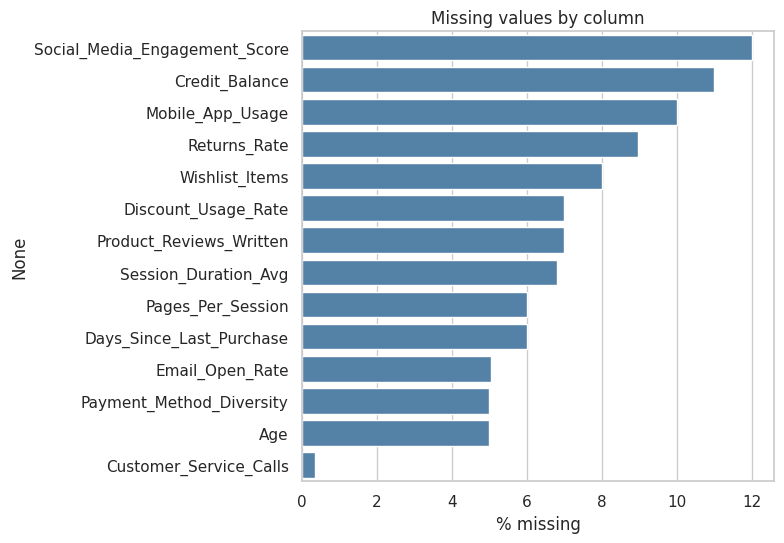

In [7]:
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing_count, "missing_pct": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_pct", ascending=False)

print(missing_summary if len(missing_summary) else "No missing values found.")

if len(missing_summary):
    plt.figure(figsize=(8, max(3, len(missing_summary) * 0.4)))
    sns.barplot(x=missing_summary["missing_pct"], y=missing_summary.index, color="steelblue")
    plt.xlabel("% missing")
    plt.title("Missing values by column")
    plt.tight_layout()
    plt.show()


## 5. Duplicates

*(MLDLC Q: Are there any duplicates?)*

In [8]:
dup_count = df.duplicated().sum()
dup_count_no_id = df.drop(columns=["Customer_ID"]).duplicated().sum()
print("Exact duplicate rows (incl. synthesized ID, so effectively 0 expected):", dup_count)
print("Duplicate rows ignoring Customer_ID (real signal):", dup_count_no_id)


Exact duplicate rows (incl. synthesized ID, so effectively 0 expected): 0
Duplicate rows ignoring Customer_ID (real signal): 0


## 6. Descriptive Statistics

*(MLDLC Q: How does the data look mathematically?)*

In [9]:
display(df[expected_numeric].describe().T)


,count,mean,std,min,25%,50%,75%,max
Age,47505.0,37.802968,11.834668,5.00,29.0000,38.000,46.00,200.000000
Membership_Years,50000.0,2.984009,2.059105,0.10,1.4000,2.500,4.00,10.000000
Login_Frequency,50000.0,11.624660,7.810657,0.00,6.0000,11.000,17.00,46.000000
Session_Duration_Avg,46601.0,27.660754,10.871013,1.00,19.7000,26.800,34.70,75.600000
Pages_Per_Session,47000.0,8.737811,3.778220,1.00,6.0000,8.400,11.20,24.100000
Cart_Abandonment_Rate,50000.0,57.079973,16.282723,0.00,46.4000,58.100,68.70,143.743350
Wishlist_Items,46000.0,4.298391,3.189754,0.00,2.0000,4.000,6.00,28.000000
Total_Purchases,50000.0,13.111576,7.017312,-13.00,8.0000,12.000,17.00,128.700000
Average_Order_Value,50000.0,123.117330,175.569714,26.38,87.0500,112.970,144.44,9666.379178
Days_Since_Last_Purchase,47000.0,29.792872,29.695062,0.00,9.0000,21.000,41.00,287.000000


In [10]:
display(df[expected_categorical].describe().T)


,count,unique,top,freq
Gender,50000,3,Female,25116
Country,50000,8,USA,17384
City,50000,40,Houston,3549
Signup_Quarter,50000,4,Q3,12558


## 7. Target Variable — `Churned`

This number decides whether SMOTE, class-weighting, or both get used later — read it carefully.

Churned value counts:
Churned
0    35550
1    14450
Name: count, dtype: int64

Churned percentage:
Churned
0    71.1
1    28.9
Name: count, dtype: float64

Imbalance ratio (majority:minority): 2.46 : 1


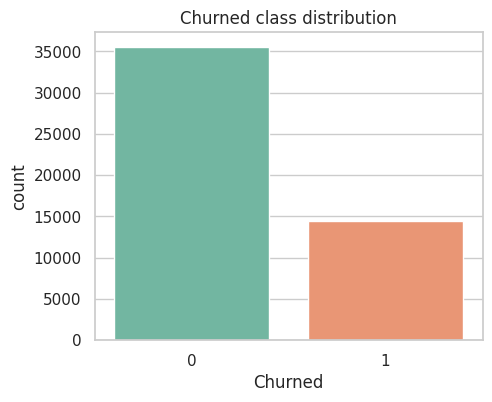

In [11]:
churn_counts = df["Churned"].value_counts(dropna=False)
churn_pct = (churn_counts / len(df) * 100).round(2)
print("Churned value counts:")
print(churn_counts)
print()
print("Churned percentage:")
print(churn_pct)

imbalance_ratio = churn_counts.max() / churn_counts.min()
print(f"\nImbalance ratio (majority:minority): {imbalance_ratio:.2f} : 1")

plt.figure(figsize=(5, 4))
sns.countplot(x="Churned", data=df, palette="Set2")
plt.title("Churned class distribution")
plt.show()


## 8. Univariate Analysis — Numeric Features

*(MLDLC Step 5: distribution analysis)*

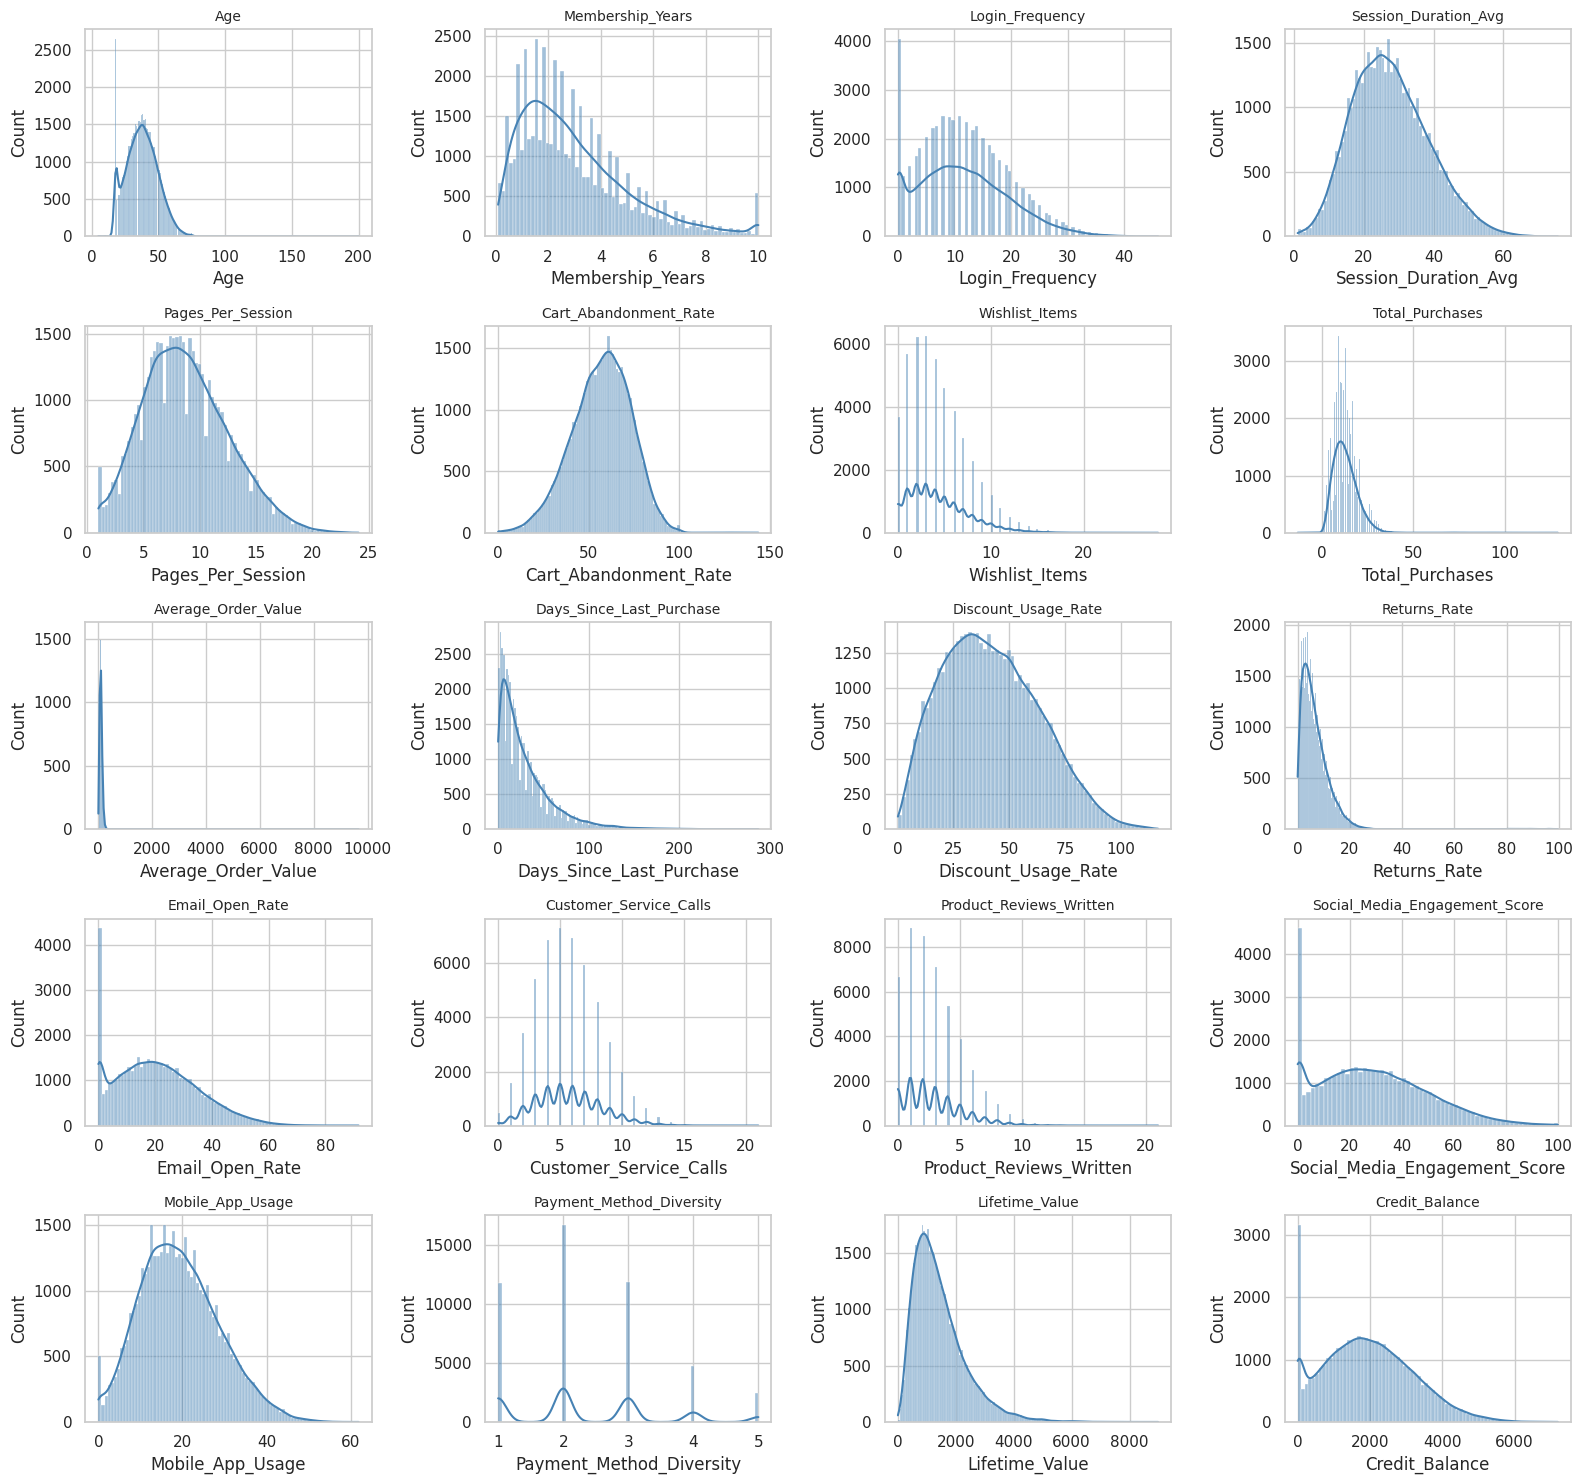

In [12]:
n_cols = 4
n_rows = int(np.ceil(len(expected_numeric) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(expected_numeric):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(col, fontsize=10)

for j in range(len(expected_numeric), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## 9. Univariate Analysis — Categorical Features

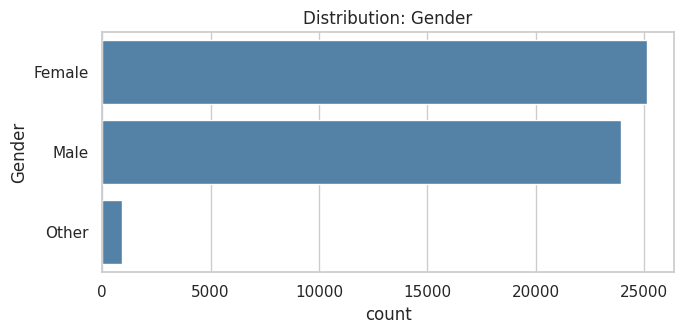

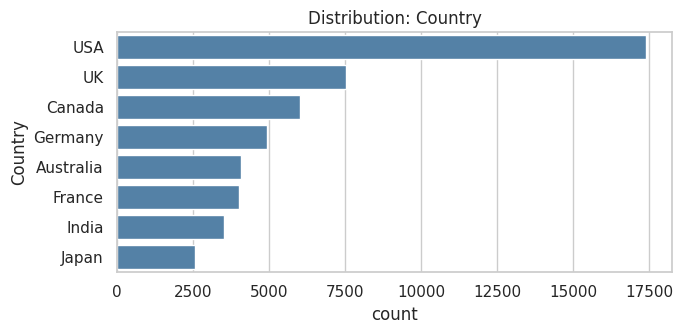

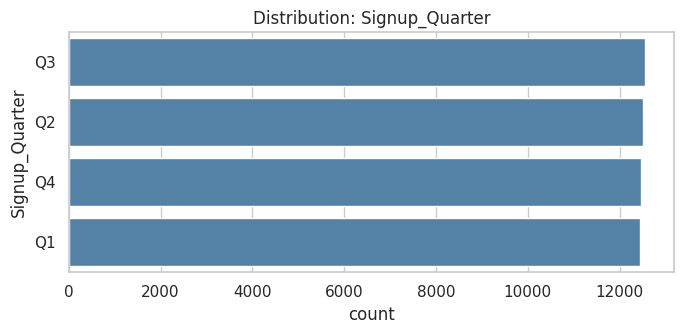

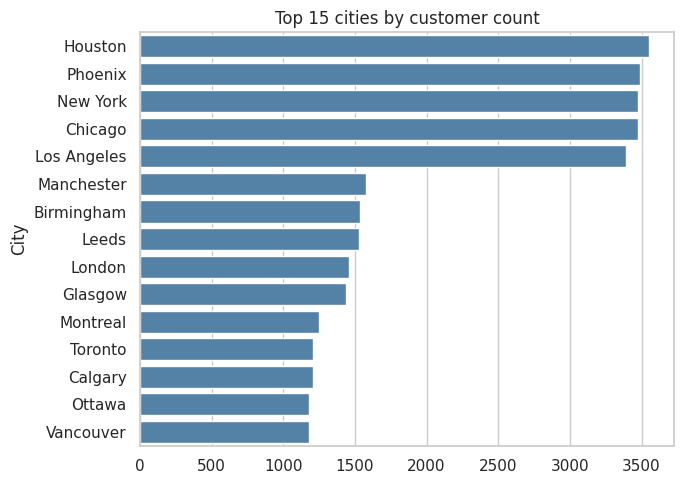

Unique countries: 8
Unique cities: 40


In [13]:
for col in ["Gender", "Country", "Signup_Quarter"]:
    plt.figure(figsize=(7, 3.5))
    order = df[col].value_counts().index
    sns.countplot(y=col, data=df, order=order, color="steelblue")
    plt.title(f"Distribution: {col}")
    plt.tight_layout()
    plt.show()

# City likely has many unique values — show top 15 only
plt.figure(figsize=(7, 5))
top_cities = df["City"].value_counts().head(15)
sns.barplot(x=top_cities.values, y=top_cities.index, color="steelblue")
plt.title("Top 15 cities by customer count")
plt.tight_layout()
plt.show()

print("Unique countries:", df["Country"].nunique())
print("Unique cities:", df["City"].nunique())


## 10. Bivariate Analysis — Numeric Features vs `Churned`

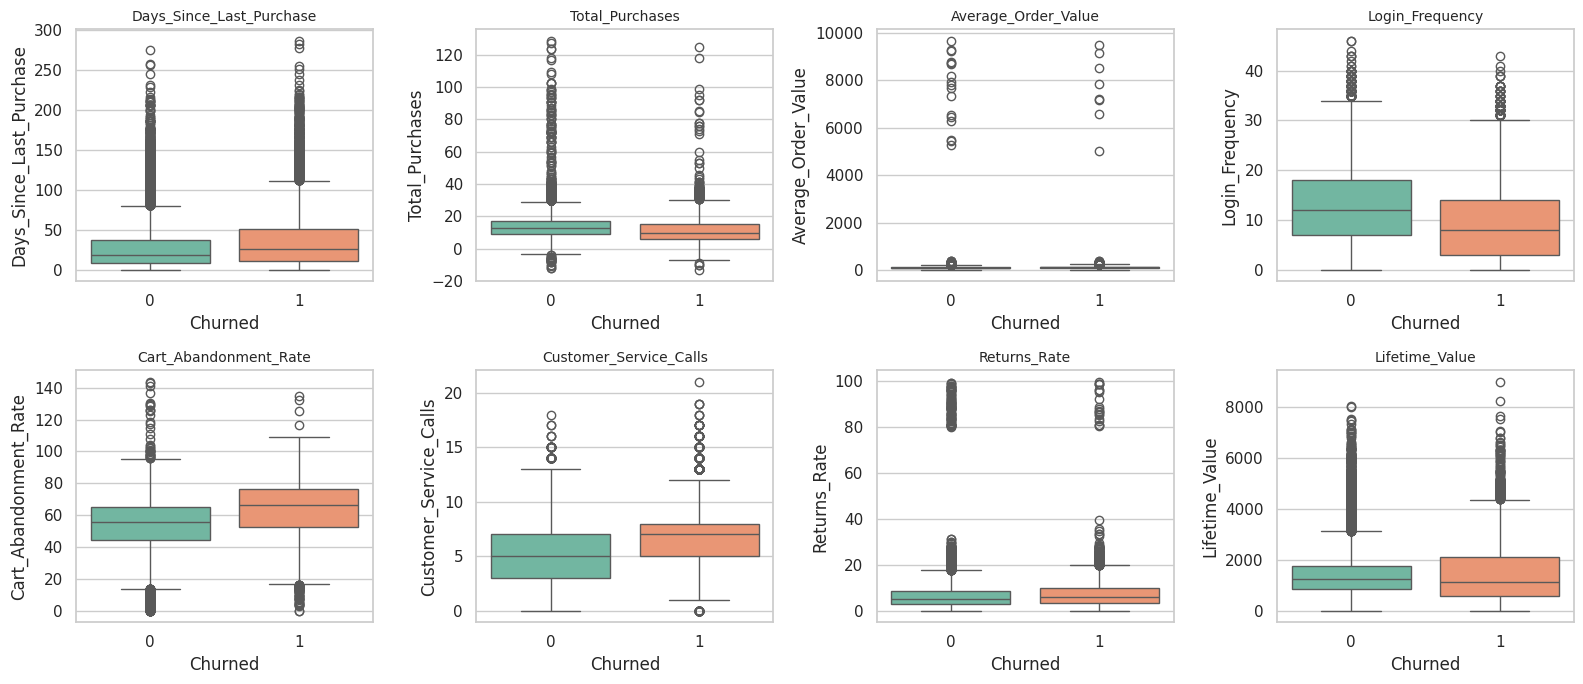

In [14]:
key_numeric_for_churn = [
    "Days_Since_Last_Purchase", "Total_Purchases", "Average_Order_Value", "Login_Frequency",
    "Cart_Abandonment_Rate", "Customer_Service_Calls", "Returns_Rate", "Lifetime_Value",
]

n_cols = 4
n_rows = int(np.ceil(len(key_numeric_for_churn) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(key_numeric_for_churn):
    sns.boxplot(x="Churned", y=col, data=df, ax=axes[i], palette="Set2")
    axes[i].set_title(col, fontsize=10)

for j in range(len(key_numeric_for_churn), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## 11. Bivariate Analysis — Categorical Features vs `Churned` (Churn Rate by Group)


Churn rate by Gender:
Gender
Other     31.27
Female    28.97
Male      28.73
Name: Churned, dtype: float64


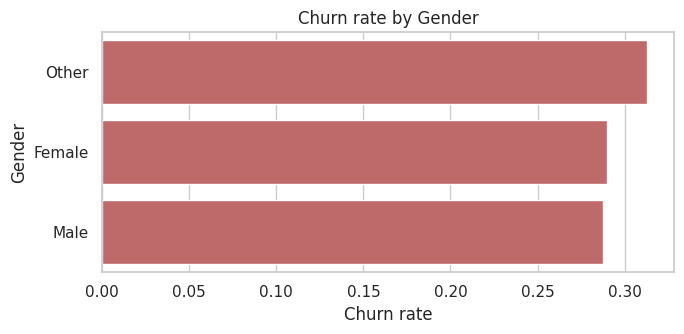


Churn rate by Country:
Country
Australia    29.89
Canada       29.35
USA          29.08
India        29.01
Germany      28.83
UK           28.79
Japan        27.83
France       27.29
Name: Churned, dtype: float64


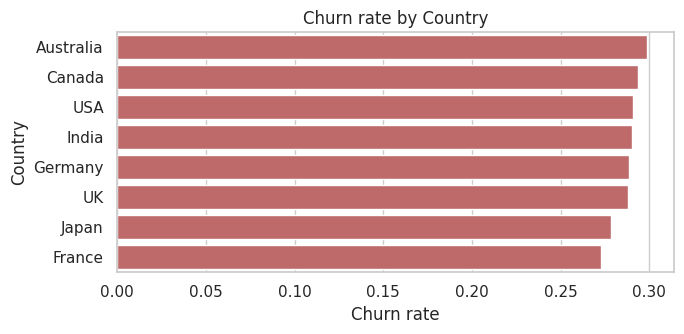


Churn rate by Signup_Quarter:
Signup_Quarter
Q2    29.67
Q1    29.32
Q3    28.43
Q4    28.18
Name: Churned, dtype: float64


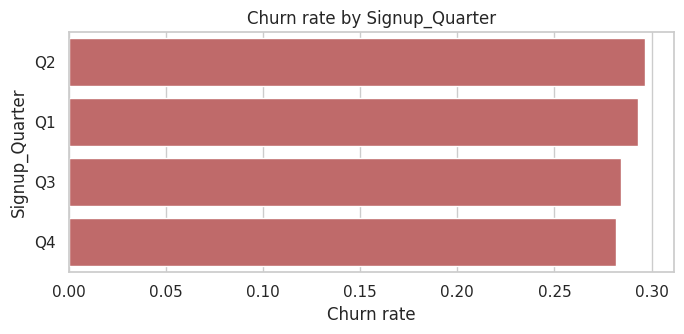

In [15]:
for col in ["Gender", "Country", "Signup_Quarter"]:
    churn_rate_by_group = df.groupby(col)["Churned"].mean().sort_values(ascending=False)
    print(f"\nChurn rate by {col}:")
    print((churn_rate_by_group * 100).round(2))

    plt.figure(figsize=(7, 3.5))
    sns.barplot(x=churn_rate_by_group.values, y=churn_rate_by_group.index, color="indianred")
    plt.xlabel("Churn rate")
    plt.title(f"Churn rate by {col}")
    plt.tight_layout()
    plt.show()


## 12. Correlation Analysis

*(MLDLC Q: Are there relationships between features?)*

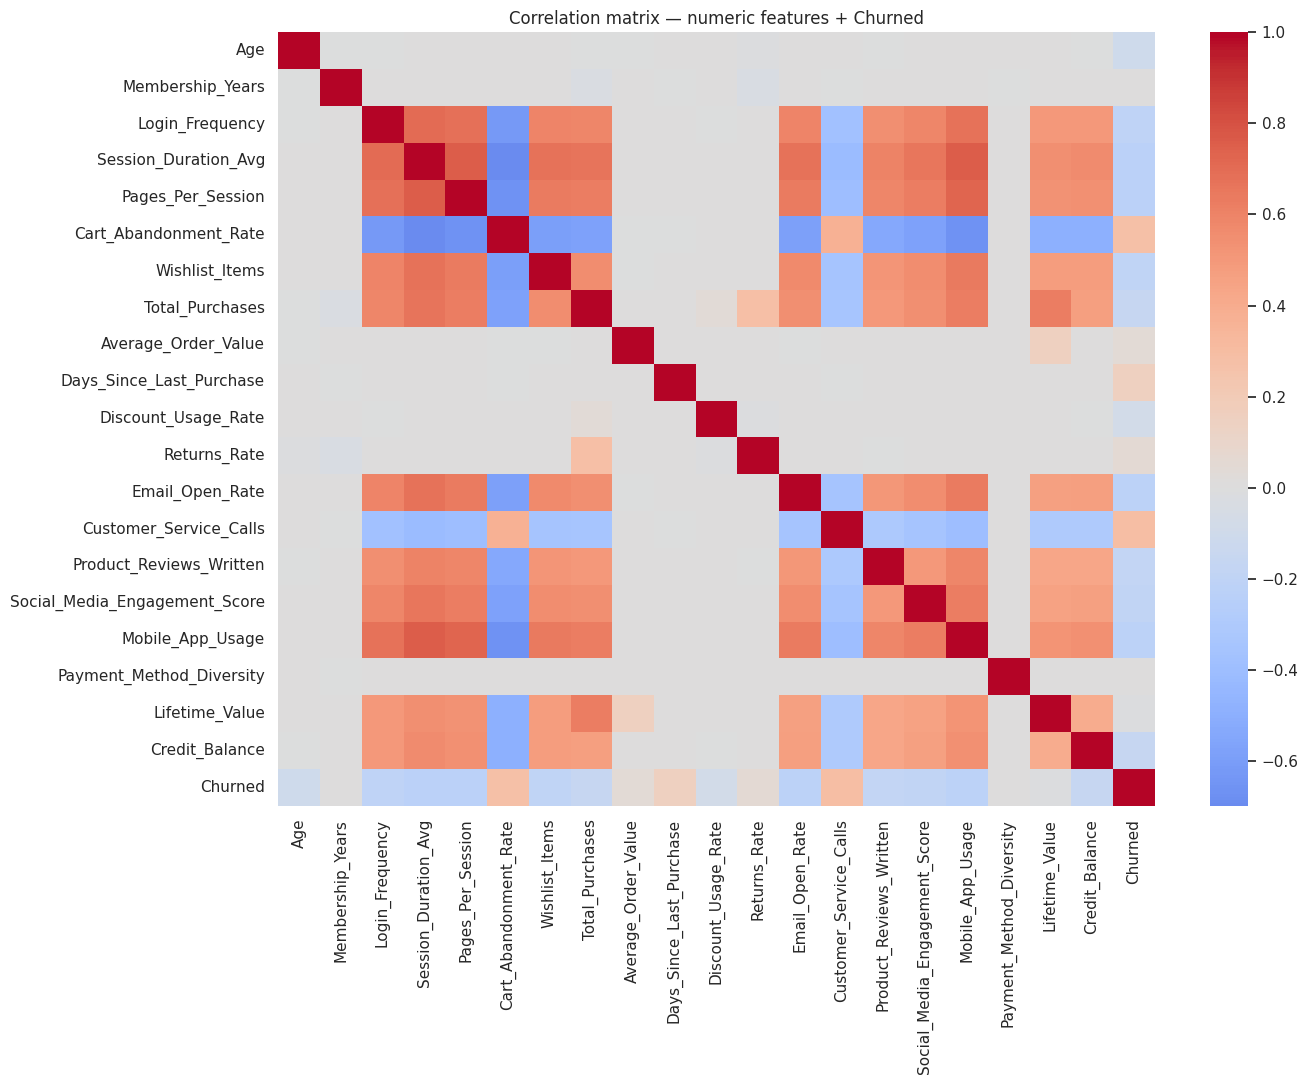

Correlation with Churned, sorted:
Customer_Service_Calls           0.291103
Cart_Abandonment_Rate            0.277963
Days_Since_Last_Purchase         0.153360
Returns_Rate                     0.054189
Average_Order_Value              0.042288
Payment_Method_Diversity         0.004524
Membership_Years                -0.000623
Lifetime_Value                  -0.010684
Discount_Usage_Rate             -0.077121
Age                             -0.102849
Credit_Balance                  -0.156921
Total_Purchases                 -0.160029
Product_Reviews_Written         -0.181225
Social_Media_Engagement_Score   -0.191792
Wishlist_Items                  -0.197708
Login_Frequency                 -0.204379
Email_Open_Rate                 -0.222213
Mobile_App_Usage                -0.222876
Session_Duration_Avg            -0.228010
Pages_Per_Session               -0.231799
Name: Churned, dtype: float64


In [16]:
corr_matrix = df[expected_numeric + ["Churned"]].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation matrix — numeric features + Churned")
plt.tight_layout()
plt.show()

print("Correlation with Churned, sorted:")
print(corr_matrix["Churned"].drop("Churned").sort_values(ascending=False))


In [17]:
# Flag any pairs of features that are strongly correlated with EACH OTHER (not the target) —
# relevant later for feature selection / multicollinearity.
corr_no_target = df[expected_numeric].corr().abs()
pairs = (
    corr_no_target.where(np.triu(np.ones(corr_no_target.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)
strong_pairs = pairs[pairs > 0.6]
print("Feature pairs with |correlation| > 0.6 (candidates for redundancy):")
print(strong_pairs if len(strong_pairs) else "None found.")


Feature pairs with |correlation| > 0.6 (candidates for redundancy):
Session_Duration_Avg           Pages_Per_Session                0.756304
                               Mobile_App_Usage                 0.755931
Pages_Per_Session              Mobile_App_Usage                 0.724334
Login_Frequency                Session_Duration_Avg             0.703510
Session_Duration_Avg           Cart_Abandonment_Rate            0.698464
Login_Frequency                Pages_Per_Session                0.675544
                               Mobile_App_Usage                 0.674695
Session_Duration_Avg           Wishlist_Items                   0.669644
Cart_Abandonment_Rate          Mobile_App_Usage                 0.669626
Session_Duration_Avg           Email_Open_Rate                  0.669150
Pages_Per_Session              Cart_Abandonment_Rate            0.668503
Session_Duration_Avg           Total_Purchases                  0.662249
                               Social_Media_Engagement_S

## 13. Outlier Detection

IQR-based outlier counts per numeric column — not removing anything here, just measuring.

In [18]:
outlier_counts = {}
for col in expected_numeric:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_counts[col] = int(((df[col] < lower) | (df[col] > upper)).sum())

outlier_df = pd.Series(outlier_counts).sort_values(ascending=False)
print("Outlier count per column (IQR method):")
print(outlier_df)


Outlier count per column (IQR method):
Payment_Method_Diversity         2439
Days_Since_Last_Purchase         2313
Lifetime_Value                   1684
Membership_Years                 1581
Returns_Rate                     1204
Customer_Service_Calls           1185
Product_Reviews_Written          1090
Average_Order_Value              1005
Wishlist_Items                    858
Total_Purchases                   628
Cart_Abandonment_Rate             323
Login_Frequency                   309
Session_Duration_Avg              300
Pages_Per_Session                 275
Mobile_App_Usage                  270
Email_Open_Rate                   238
Social_Media_Engagement_Score     233
Credit_Balance                    209
Age                               126
Discount_Usage_Rate               101
dtype: int64


## 14. `Signup_Quarter` Distribution

This directly determines whether Phase 5's walk-forward validation has enough distinct, reasonably-sized time buckets to work with.

Customers per signup quarter:
Signup_Quarter
Q1    12453
Q2    12521
Q3    12558
Q4    12468
Name: count, dtype: int64

Number of distinct quarters: 4


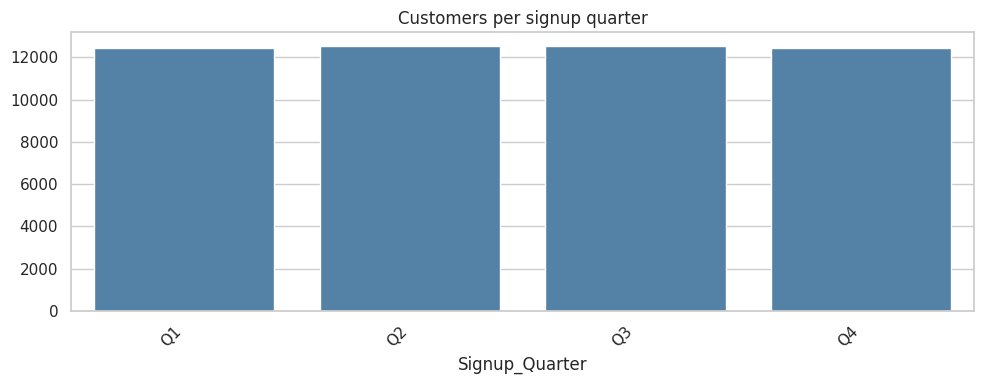

In [19]:
quarter_counts = df["Signup_Quarter"].value_counts().sort_index()
print("Customers per signup quarter:")
print(quarter_counts)
print(f"\nNumber of distinct quarters: {df['Signup_Quarter'].nunique()}")

plt.figure(figsize=(10, 4))
sns.barplot(x=quarter_counts.index, y=quarter_counts.values, color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.title("Customers per signup quarter")
plt.tight_layout()
plt.show()


## 15. `Lifetime_Value` Sanity Checks

This is the real regression target for Phase 5's LTV model — worth a direct look, not just a line in the correlation matrix.

count    50000.000000
mean      1440.626292
std        907.249443
min          0.000000
25%        789.817500
50%       1243.415000
75%       1874.000000
max       8987.240000
Name: Lifetime_Value, dtype: float64


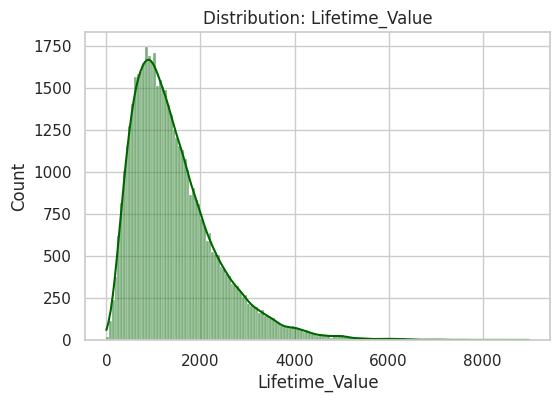


Lifetime_Value correlation with purchase-related features:
Lifetime_Value         1.000000
Total_Purchases        0.622778
Average_Order_Value    0.151574
Membership_Years       0.003583
Name: Lifetime_Value, dtype: float64


In [20]:
print(df["Lifetime_Value"].describe())

plt.figure(figsize=(6, 4))
sns.histplot(df["Lifetime_Value"].dropna(), kde=True, color="darkgreen")
plt.title("Distribution: Lifetime_Value")
plt.show()

ltv_corr = df[["Lifetime_Value", "Total_Purchases", "Average_Order_Value", "Membership_Years"]].corr()["Lifetime_Value"]
print("\nLifetime_Value correlation with purchase-related features:")
print(ltv_corr.sort_values(ascending=False))


## 16. Summary — copy this block back into chat

One clean, structured printout. Nothing here is a decision — decisions get made in the next notebook, from this.

In [21]:
summary = {
    "shape": df.shape,
    "missing_by_column_pct": missing_pct[missing_pct > 0].to_dict(),
    "duplicate_rows_ignoring_id": int(dup_count_no_id),
    "churn_counts": churn_counts.to_dict(),
    "churn_pct": churn_pct.to_dict(),
    "imbalance_ratio": round(float(imbalance_ratio), 2),
    "top_correlations_with_churned": corr_matrix["Churned"].drop("Churned").sort_values(ascending=False).round(3).to_dict(),
    "strong_feature_pairs_gt_0_6": {f"{a} | {b}": round(float(v), 3) for (a, b), v in strong_pairs.items()} if len(strong_pairs) else {},
    "outlier_counts": outlier_df.to_dict(),
    "signup_quarter_counts": quarter_counts.to_dict(),
    "num_distinct_quarters": int(df["Signup_Quarter"].nunique()),
    "lifetime_value_describe": df["Lifetime_Value"].describe().round(2).to_dict(),
    "unique_countries": int(df["Country"].nunique()),
    "unique_cities": int(df["City"].nunique()),
}

import json
print(json.dumps(summary, indent=2, default=str))


{
  "shape": [
    50000,
    26
  ],
  "missing_by_column_pct": {
    "Age": 4.99,
    "Session_Duration_Avg": 6.8,
    "Pages_Per_Session": 6.0,
    "Wishlist_Items": 8.0,
    "Days_Since_Last_Purchase": 6.0,
    "Discount_Usage_Rate": 7.0,
    "Returns_Rate": 8.98,
    "Email_Open_Rate": 5.06,
    "Customer_Service_Calls": 0.34,
    "Product_Reviews_Written": 7.0,
    "Social_Media_Engagement_Score": 12.0,
    "Mobile_App_Usage": 10.0,
    "Payment_Method_Diversity": 5.0,
    "Credit_Balance": 11.0
  },
  "duplicate_rows_ignoring_id": 0,
  "churn_counts": {
    "0": 35550,
    "1": 14450
  },
  "churn_pct": {
    "0": 71.1,
    "1": 28.9
  },
  "imbalance_ratio": 2.46,
  "top_correlations_with_churned": {
    "Customer_Service_Calls": 0.291,
    "Cart_Abandonment_Rate": 0.278,
    "Days_Since_Last_Purchase": 0.153,
    "Returns_Rate": 0.054,
    "Average_Order_Value": 0.042,
    "Payment_Method_Diversity": 0.005,
    "Membership_Years": -0.001,
    "Lifetime_Value": -0.011,
    "Dis